In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
customers = pd.read_excel(
    "Banking_Customer_Analytics_Dataset.xlsx",
    sheet_name="Customers"
)

transactions = pd.read_excel(
    "Banking_Customer_Analytics_Dataset.xlsx",
    sheet_name="Transactions"
)

print("Customers:", customers.shape)
print("Transactions:", transactions.shape)

Customers: (5000, 18)
Transactions: (50000, 7)


In [3]:
customers.head()

,Customer_ID,Age,Gender,City,Branch,Account_Type,Customer_Since,Monthly_Income,Account_Balance,Credit_Score,Loan_Status,Loan_Type,Loan_Amount,Digital_Banking,Customer_Status,Age_Group,Income_Segment,Customer_Segment
0,CUST00001,34,Female,Latur,Latur Main,Premium Savings,2018,138800,1106000,682,No Loan,NaN,0,Yes,Active,31-40,100K-250K,Premium
1,CUST00002,21,Male,Satara,Satara Main,Current,2025,35600,162600,580,No Loan,NaN,0,Yes,Active,21-30,30K-60K,Mass Affluent
2,CUST00003,35,Female,Aurangabad,Aurangabad Main,Savings,2020,38900,102000,662,No Loan,NaN,0,Yes,Active,31-40,30K-60K,Mass Affluent
3,CUST00004,59,Male,Nashik,Nashik Main,Savings,2023,24500,130200,727,Active,Home Loan,610000,No,Dormant,51-60,<30K,Mass Affluent
4,CUST00005,46,Male,Pune,Hadapsar,Savings,2015,52300,196100,709,No Loan,NaN,0,Yes,Dormant,41-50,30K-60K,Mass Affluent


In [4]:
customers.tail()

,Customer_ID,Age,Gender,City,Branch,Account_Type,Customer_Since,Monthly_Income,Account_Balance,Credit_Score,Loan_Status,Loan_Type,Loan_Amount,Digital_Banking,Customer_Status,Age_Group,Income_Segment,Customer_Segment
4995,CUST04996,36,Female,Sangli,Sangli Main,Premium Savings,2020,31200,95900,699,No Loan,NaN,0,Yes,Active,31-40,30K-60K,Mass
4996,CUST04997,42,Male,Pune,Pune Camp,Savings,2023,42100,86800,735,No Loan,NaN,0,Yes,Active,41-50,30K-60K,Mass
4997,CUST04998,21,Female,Latur,Ausa Road,Premium Savings,2024,46700,125900,751,No Loan,NaN,0,No,Active,21-30,30K-60K,Mass Affluent
4998,CUST04999,27,Female,Nagpur,Nagpur Main,Savings,2018,16800,61400,741,No Loan,NaN,0,No,Active,21-30,<30K,Mass
4999,CUST05000,50,Male,Nashik,Nashik Main,Current,2022,32100,194700,742,No Loan,NaN,0,Yes,Dormant,41-50,30K-60K,Mass Affluent


In [5]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Customer_ID       5000 non-null   str  
 1   Age               5000 non-null   int64
 2   Gender            5000 non-null   str  
 3   City              5000 non-null   str  
 4   Branch            5000 non-null   str  
 5   Account_Type      5000 non-null   str  
 6   Customer_Since    5000 non-null   int64
 7   Monthly_Income    5000 non-null   int64
 8   Account_Balance   5000 non-null   int64
 9   Credit_Score      5000 non-null   int64
 10  Loan_Status       5000 non-null   str  
 11  Loan_Type         1942 non-null   str  
 12  Loan_Amount       5000 non-null   int64
 13  Digital_Banking   5000 non-null   str  
 14  Customer_Status   5000 non-null   str  
 15  Age_Group         5000 non-null   str  
 16  Income_Segment    5000 non-null   str  
 17  Customer_Segment  5000 non-null   str  
dtyp

In [6]:
customers.isnull().sum()

Customer_ID            0
Age                    0
Gender                 0
City                   0
Branch                 0
Account_Type           0
Customer_Since         0
Monthly_Income         0
Account_Balance        0
Credit_Score           0
Loan_Status            0
Loan_Type           3058
Loan_Amount            0
Digital_Banking        0
Customer_Status        0
Age_Group              0
Income_Segment         0
Customer_Segment       0
dtype: int64

In [8]:
customers["Customer_ID"].duplicated().sum()

np.int64(0)

In [9]:
total_balance = customers["Account_Balance"].sum()

print("Total Customer Balance: ₹{:,.0f}".format(total_balance))

Total Customer Balance: ₹1,408,521,100


In [10]:
average_balance = customers["Account_Balance"].mean()

print("Average Customer Balance: ₹{:,.0f}".format(average_balance))

Average Customer Balance: ₹281,704


In [11]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Total Customer Balance",
        "Average Customer Balance",
        "Total Loan Portfolio",
        "Active Customers",
        "Digital Banking Customers"
    ],
    "Value": [
        customers["Customer_ID"].nunique(),
        customers["Account_Balance"].sum(),
        customers["Account_Balance"].mean(),
        customers["Loan_Amount"].sum(),
        (customers["Customer_Status"] == "Active").sum(),
        (customers["Digital_Banking"] == "Yes").sum()
    ]
})

kpi_summary

,Metric,Value
0,Total Customers,5.000000e+03
1,Total Customer Balance,1.408521e+09
2,Average Customer Balance,2.817042e+05
3,Total Loan Portfolio,1.391033e+09
4,Active Customers,4.547000e+03
5,Digital Banking Customers,3.555000e+03


In [12]:
missing_values = customers.isnull().sum()

missing_values[missing_values > 0]

Loan_Type    3058
dtype: int64

In [13]:
pd.crosstab(
    customers["Loan_Status"],
    customers["Loan_Type"]
)

Loan_Type,Education Loan,Home Loan,Personal Loan,Vehicle Loan
Loan_Status,,,,
Active,204,485,799,454


In [14]:
customers["Customer_ID"].duplicated().sum()

np.int64(0)

In [15]:
gender_analysis = (
    customers["Gender"]
    .value_counts()
    .reset_index()
)

gender_analysis.columns = ["Gender", "Customers"]

gender_analysis

,Gender,Customers
0,Male,2768
1,Female,2232


In [16]:
account_analysis = (
    customers["Account_Type"]
    .value_counts()
    .reset_index()
)

account_analysis.columns = ["Account_Type", "Customers"]

account_analysis

,Account_Type,Customers
0,Savings,2750
1,Salary,974
2,Premium Savings,674
3,Current,602


In [17]:
age_analysis = (
    customers["Age_Group"]
    .value_counts()
    .sort_index()
)

age_analysis

Age_Group
21-30    1229
31-40    1548
41-50    1358
51-60     673
61+       192
Name: count, dtype: int64

In [18]:
balance_analysis = (
    customers
    .groupby("Customer_Segment", observed=True)
    .agg(
        Customers=("Customer_ID", "count"),
        Total_Balance=("Account_Balance", "sum"),
        Average_Balance=("Account_Balance", "mean")
    )
    .reset_index()
)

balance_analysis

,Customer_Segment,Customers,Total_Balance,Average_Balance
0,Affluent,571,383256400,6.712021e+05
1,Mass,845,57167500,6.765385e+04
2,Mass Affluent,3488,843228200,2.417512e+05
3,Premium,96,124869000,1.300719e+06


In [19]:
balance_analysis.sort_values(
    "Total_Balance",
    ascending=False
)

,Customer_Segment,Customers,Total_Balance,Average_Balance
2,Mass Affluent,3488,843228200,2.417512e+05
0,Affluent,571,383256400,6.712021e+05
3,Premium,96,124869000,1.300719e+06
1,Mass,845,57167500,6.765385e+04


In [20]:
branch_analysis = (
    customers
    .groupby("Branch")
    .agg(
        Customers=("Customer_ID", "count"),
        Total_Balance=("Account_Balance", "sum"),
        Average_Balance=("Account_Balance", "mean"),
        Total_Loans=("Loan_Amount", "sum")
    )
    .reset_index()
)

branch_analysis.sort_values(
    "Total_Balance",
    ascending=False
)

,Branch,Customers,Total_Balance,Average_Balance,Total_Loans
8,Kolhapur Main,411,111224500,270619.221411,110829000
0,Akkalkot Road,329,95077300,288988.753799,89764000
17,Solapur Main,327,88442900,270467.584098,88862000
14,Pune Main,290,83095200,286535.172414,64377000
15,Sangli Main,273,83093000,304369.963370,82135000
16,Satara Main,305,82120200,269246.557377,80101000
11,Nashik Main,257,78824400,306709.727626,81385000
12,Panchavati,264,72328700,273972.348485,68337000
1,Andheri,256,71964000,281109.375000,86901000
5,Dadar,242,71687800,296230.578512,69618000


In [21]:
branch_analysis.loc[
    branch_analysis["Total_Balance"].idxmax()
]

Branch             Kolhapur Main
Customers                    411
Total_Balance          111224500
Average_Balance    270619.221411
Total_Loans            110829000
Name: 8, dtype: object

In [22]:
branch_analysis.loc[
    branch_analysis["Total_Loans"].idxmax()
]

Branch             Kolhapur Main
Customers                    411
Total_Balance          111224500
Average_Balance    270619.221411
Total_Loans            110829000
Name: 8, dtype: object

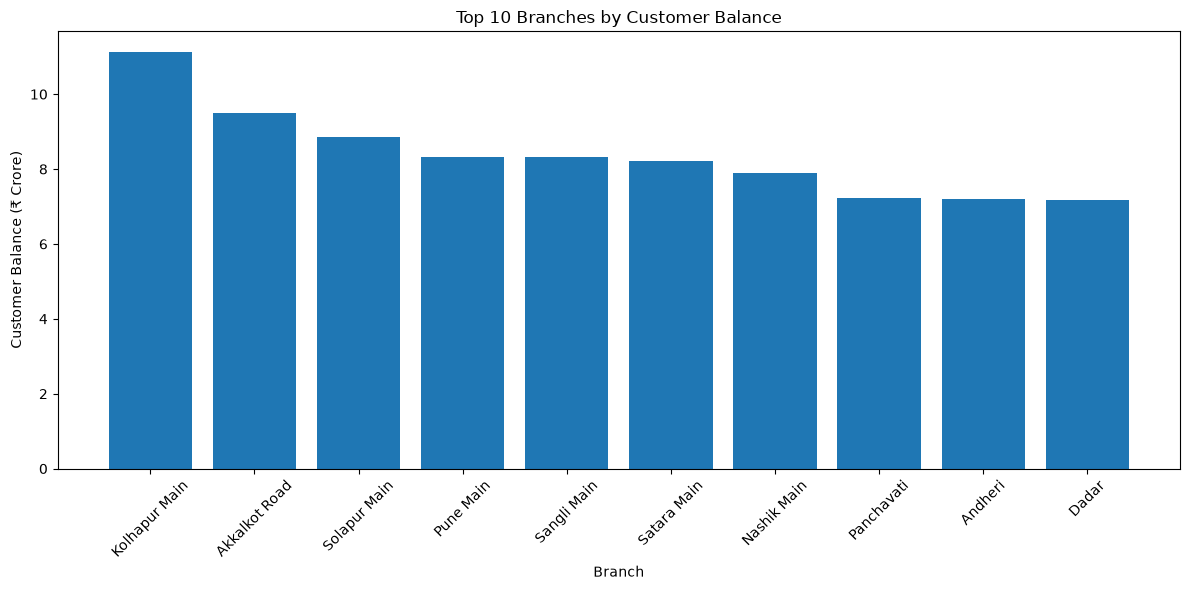

In [23]:
top_branches = (
    branch_analysis
    .sort_values("Total_Balance", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

plt.bar(
    top_branches["Branch"],
    top_branches["Total_Balance"] / 10000000
)

plt.title("Top 10 Branches by Customer Balance")
plt.xlabel("Branch")
plt.ylabel("Customer Balance (₹ Crore)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [24]:
high_value_customers = customers[
    customers["Account_Balance"] >= 500000
].copy()

print("High-value customers:", len(high_value_customers))

High-value customers: 667


In [25]:
high_value_customers[
    [
        "Customer_ID",
        "Age",
        "City",
        "Branch",
        "Account_Balance",
        "Monthly_Income",
        "Credit_Score",
        "Customer_Segment"
    ]
].sort_values(
    "Account_Balance",
    ascending=False
).head(10)

,Customer_ID,Age,City,Branch,Account_Balance,Monthly_Income,Credit_Score,Customer_Segment
4644,CUST04645,32,Kolhapur,Kolhapur Main,2782100,173300,651,Premium
126,CUST00127,38,Nagpur,Dharampeth,2504300,229300,716,Premium
3811,CUST03812,57,Mumbai,Dadar,2153400,207500,647,Premium
3491,CUST03492,28,Nashik,Nashik Main,2140500,239400,671,Premium
452,CUST00453,31,Mumbai,Andheri,1960700,149900,699,Premium
1148,CUST01149,26,Nagpur,Nagpur Main,1894000,216400,603,Premium
1146,CUST01147,26,Aurangabad,Aurangabad Main,1847600,187300,757,Premium
4353,CUST04354,56,Satara,Satara Main,1796700,177900,689,Premium
117,CUST00118,45,Solapur,Akkalkot Road,1714900,74000,768,Premium
1618,CUST01619,40,Nashik,Panchavati,1685400,128800,739,Premium


In [26]:
loan_opportunity = customers[
    (customers["Account_Balance"] >= 500000) &
    (customers["Loan_Status"] == "No Loan")
].copy()

print("Potential loan customers:", len(loan_opportunity))

Potential loan customers: 408


In [27]:
print(
    "Total balance of potential customers: ₹{:,.0f}".format(
        loan_opportunity["Account_Balance"].sum()
    )
)

Total balance of potential customers: ₹304,435,000


In [28]:
digital_opportunity = customers[
    (customers["Account_Balance"] >= 300000) &
    (customers["Digital_Banking"] == "No")
].copy()

print("Digital banking opportunity:", len(digital_opportunity))

Digital banking opportunity: 485


In [29]:
print(
    "Balance of these customers: ₹{:,.0f}".format(
        digital_opportunity["Account_Balance"].sum()
    )
)

Balance of these customers: ₹258,261,700


In [30]:
dormant_high_value = customers[
    (customers["Customer_Status"] == "Dormant") &
    (customers["Account_Balance"] >= 200000)
].copy()

print("Dormant high-value customers:", len(dormant_high_value))

Dormant high-value customers: 237


In [32]:
customers["Opportunity_Score"] = 0

customers.loc[
    customers["Account_Balance"] >= 500000,
    "Opportunity_Score"
] += 2

customers.loc[
    customers["Loan_Status"] == "No Loan",
    "Opportunity_Score"
] += 2

customers.loc[
    customers["Digital_Banking"] == "No",
    "Opportunity_Score"
] += 1

customers.loc[
    customers["Credit_Score"] >= 750,
    "Opportunity_Score"
] += 1

In [33]:
opportunity_customers = customers[
    customers["Opportunity_Score"] >= 5
].copy()

print(
    "High opportunity customers:",
    len(opportunity_customers)
)

High opportunity customers: 186


In [34]:
opportunity_customers[
    [
        "Customer_ID",
        "City",
        "Branch",
        "Account_Balance",
        "Credit_Score",
        "Loan_Status",
        "Digital_Banking",
        "Opportunity_Score"
    ]
].sort_values(
    "Opportunity_Score",
    ascending=False
).head(20)

,Customer_ID,City,Branch,Account_Balance,Credit_Score,Loan_Status,Digital_Banking,Opportunity_Score
220,CUST00221,Kolhapur,Kolhapur Main,668700,792,No Loan,No,6
158,CUST00159,Solapur,Akkalkot Road,518700,782,No Loan,No,6
473,CUST00474,Sangli,Sangli Main,904600,802,No Loan,No,6
353,CUST00354,Solapur,Solapur Main,506900,808,No Loan,No,6
1521,CUST01522,Sangli,Sangli Main,657900,786,No Loan,No,6
1146,CUST01147,Aurangabad,Aurangabad Main,1847600,757,No Loan,No,6
2491,CUST02492,Solapur,Solapur Main,604500,758,No Loan,No,6
2421,CUST02422,Pune,Pune Main,1032200,759,No Loan,No,6
4399,CUST04400,Pune,Pune Main,1405100,776,No Loan,No,6
4893,CUST04894,Solapur,Akkalkot Road,615800,798,No Loan,No,6


In [35]:
customers["Opportunity_Score"].value_counts().sort_index()

Opportunity_Score
0     925
1     642
2    1685
3    1132
4     430
5     162
6      24
Name: count, dtype: int64

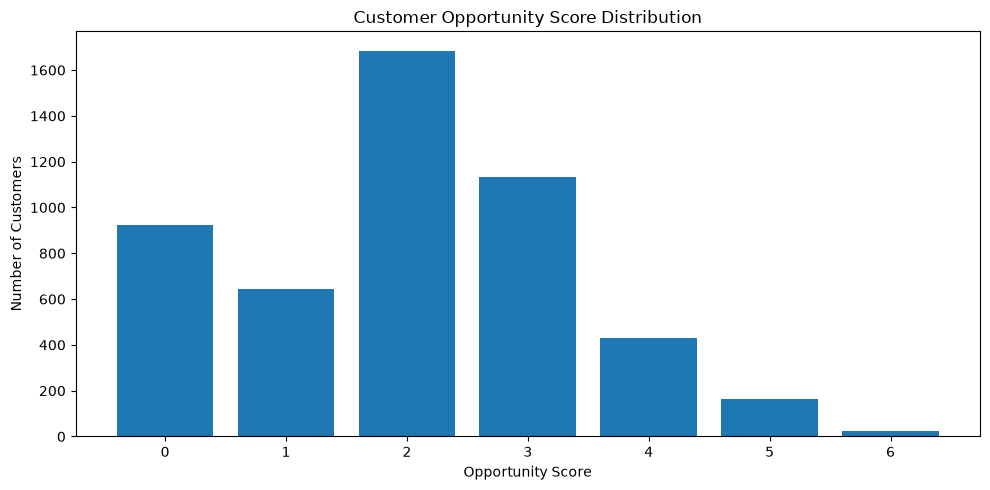

In [36]:
score_counts = (
    customers["Opportunity_Score"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))

plt.bar(
    score_counts.index.astype(str),
    score_counts.values
)

plt.title("Customer Opportunity Score Distribution")
plt.xlabel("Opportunity Score")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [37]:
transactions.head()

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Type,Amount,Channel,Branch
0,TXN0017299,CUST04047,2025-01-01,UPI Payment,2718,Internet Banking,Latur Main
1,TXN0046192,CUST00183,2025-01-01,Deposit,2289,UPI,Solapur Main
2,TXN0006516,CUST01202,2025-01-01,Withdrawal,1571,Mobile Banking,Nashik Main
3,TXN0006553,CUST00907,2025-01-01,Deposit,1279,Branch,Pune Main
4,TXN0036803,CUST02208,2025-01-01,Deposit,1859,UPI,Nagpur Main


In [38]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction_ID    50000 non-null  str           
 1   Customer_ID       50000 non-null  str           
 2   Transaction_Date  50000 non-null  datetime64[us]
 3   Transaction_Type  50000 non-null  str           
 4   Amount            50000 non-null  int64         
 5   Channel           50000 non-null  str           
 6   Branch            50000 non-null  str           
dtypes: datetime64[us](1), int64(1), str(5)
memory usage: 2.7 MB


In [40]:
transactions["Transaction_Date"] = pd.to_datetime(
    transactions["Transaction_Date"]
)

In [41]:
transactions["Transaction_Date"].dtype

dtype('<M8[us]')

In [42]:
transactions["Year"] = transactions["Transaction_Date"].dt.year

transactions["Month"] = transactions["Transaction_Date"].dt.month

transactions["Month_Name"] = transactions["Transaction_Date"].dt.strftime("%b")

transactions["Year_Month"] = (
    transactions["Transaction_Date"]
    .dt.to_period("M")
    .astype(str)
)

In [43]:
transactions[
    [
        "Transaction_Date",
        "Year",
        "Month",
        "Month_Name",
        "Year_Month"
    ]
].head()

,Transaction_Date,Year,Month,Month_Name,Year_Month
0,2025-01-01,2025,1,Jan,2025-01
1,2025-01-01,2025,1,Jan,2025-01
2,2025-01-01,2025,1,Jan,2025-01
3,2025-01-01,2025,1,Jan,2025-01
4,2025-01-01,2025,1,Jan,2025-01


In [44]:
transaction_type_analysis = (
    transactions
    .groupby("Transaction_Type")
    .agg(
        Transactions=("Transaction_ID", "count"),
        Total_Amount=("Amount", "sum"),
        Average_Amount=("Amount", "mean")
    )
    .reset_index()
)

transaction_type_analysis.sort_values(
    "Total_Amount",
    ascending=False
)

,Transaction_Type,Transactions,Total_Amount,Average_Amount
2,Loan EMI,7987,143384453,17952.228997
1,Deposit,10984,45566089,4148.405772
4,UPI Payment,9088,37442386,4119.980854
3,Transfer,8915,36825767,4130.764666
5,Withdrawal,8036,33701292,4193.789447
0,ATM Withdrawal,4990,20377476,4083.662525


In [45]:
channel_analysis = (
    transactions
    .groupby("Channel")
    .agg(
        Transactions=("Transaction_ID", "count"),
        Total_Amount=("Amount", "sum"),
        Average_Transaction=("Amount", "mean")
    )
    .reset_index()
)

channel_analysis.sort_values(
    "Transactions",
    ascending=False
)

,Channel,Transactions,Total_Amount,Average_Transaction
3,Mobile Banking,15131,95661319,6322.207323
4,UPI,10977,69139372,6298.567186
0,ATM,9065,57754447,6371.146939
2,Internet Banking,7912,51223678,6474.175683
1,Branch,6915,43518647,6293.369053


In [46]:
monthly_transactions = (
    transactions
    .groupby("Year_Month")
    .agg(
        Transactions=("Transaction_ID", "count"),
        Total_Amount=("Amount", "sum")
    )
    .reset_index()
)

monthly_transactions.head()

,Year_Month,Transactions,Total_Amount
0,2025-01,2590,15824784
1,2025-02,2335,14410084
2,2025-03,2600,16645130
3,2025-04,2674,16986507
4,2025-05,2669,16653615


In [47]:
monthly_transactions = monthly_transactions.sort_values(
    "Year_Month"
)

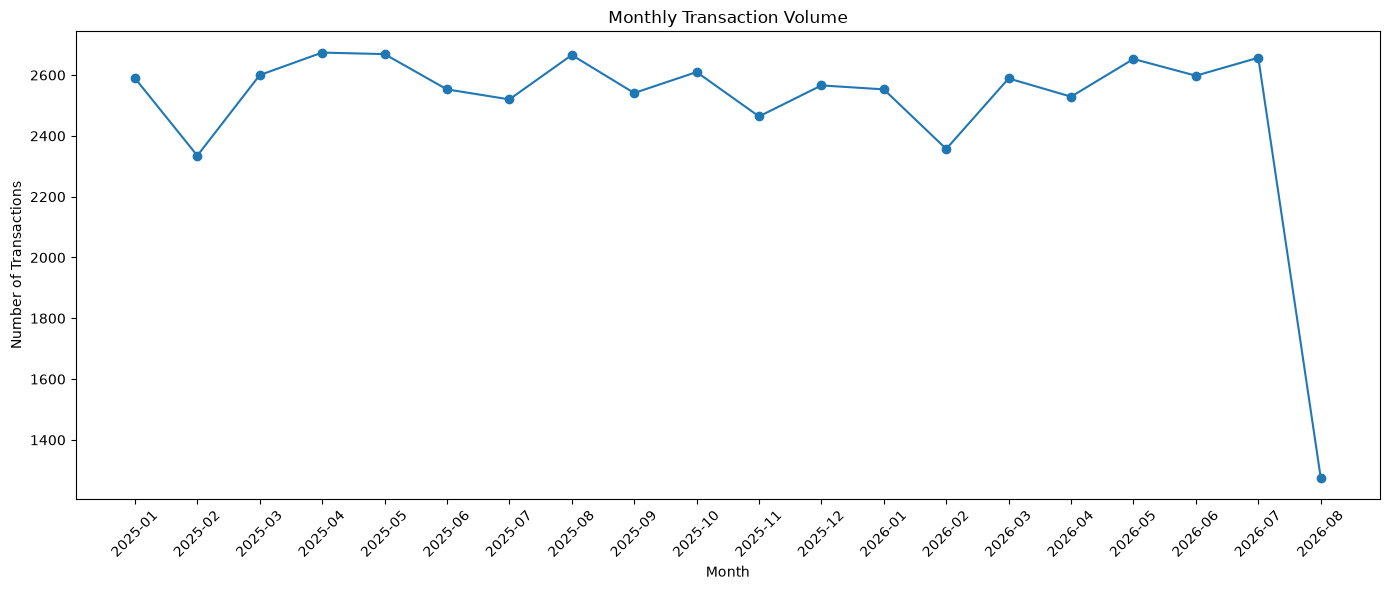

In [48]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_transactions["Year_Month"],
    monthly_transactions["Transactions"],
    marker="o"
)

plt.title("Monthly Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [49]:
deposit_withdrawal = transactions[
    transactions["Transaction_Type"].isin(
        ["Deposit", "Withdrawal"]
    )
]

deposit_withdrawal_summary = (
    deposit_withdrawal
    .groupby("Transaction_Type")
    .agg(
        Transactions=("Transaction_ID", "count"),
        Total_Amount=("Amount", "sum"),
        Average_Amount=("Amount", "mean")
    )
    .reset_index()
)

deposit_withdrawal_summary

,Transaction_Type,Transactions,Total_Amount,Average_Amount
0,Deposit,10984,45566089,4148.405772
1,Withdrawal,8036,33701292,4193.789447


In [50]:
top_transaction_customers = (
    transactions
    .groupby("Customer_ID")
    .agg(
        Transactions=("Transaction_ID", "count"),
        Total_Transaction_Value=("Amount", "sum"),
        Average_Transaction=("Amount", "mean")
    )
    .reset_index()
    .sort_values(
        "Total_Transaction_Value",
        ascending=False
    )
)

top_transaction_customers.head(10)

,Customer_ID,Transactions,Total_Transaction_Value,Average_Transaction
2117,CUST02118,12,243755,20312.916667
1738,CUST01739,9,229724,25524.888889
608,CUST00609,15,215971,14398.066667
4191,CUST04192,16,208702,13043.875000
1502,CUST01503,21,206811,9848.142857
3819,CUST03820,26,194640,7486.153846
4094,CUST04095,15,193564,12904.266667
4634,CUST04635,16,192789,12049.312500
880,CUST00881,16,192318,12019.875000
3172,CUST03173,14,184614,13186.714286


In [51]:
analysis_df = customers.copy()

print("Analysis dataset:", analysis_df.shape)

Analysis dataset: (5000, 19)


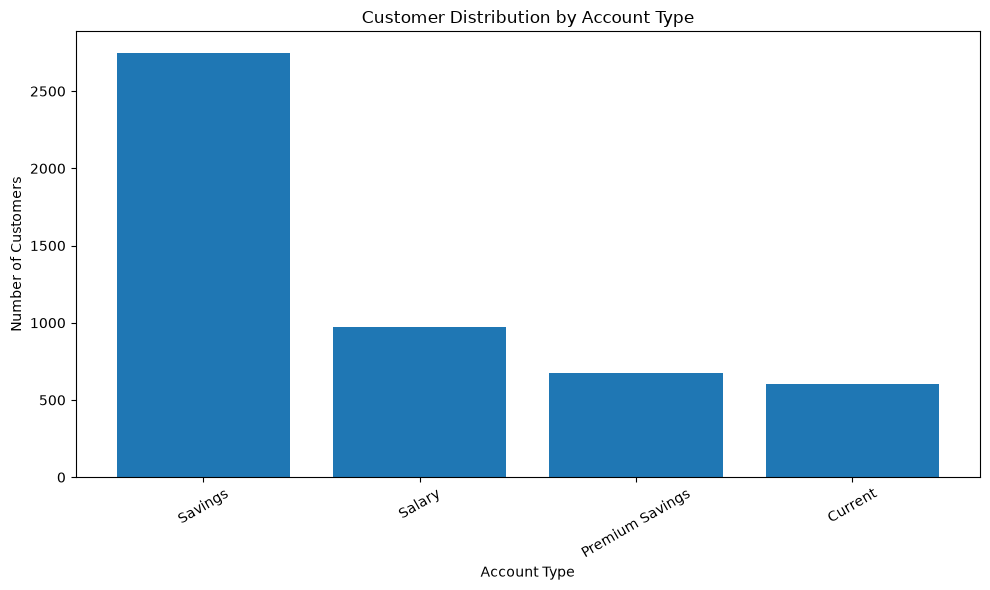

In [52]:
account_counts = (
    customers["Account_Type"]
    .value_counts()
)

plt.figure(figsize=(10, 6))

plt.bar(
    account_counts.index,
    account_counts.values
)

plt.title("Customer Distribution by Account Type")
plt.xlabel("Account Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

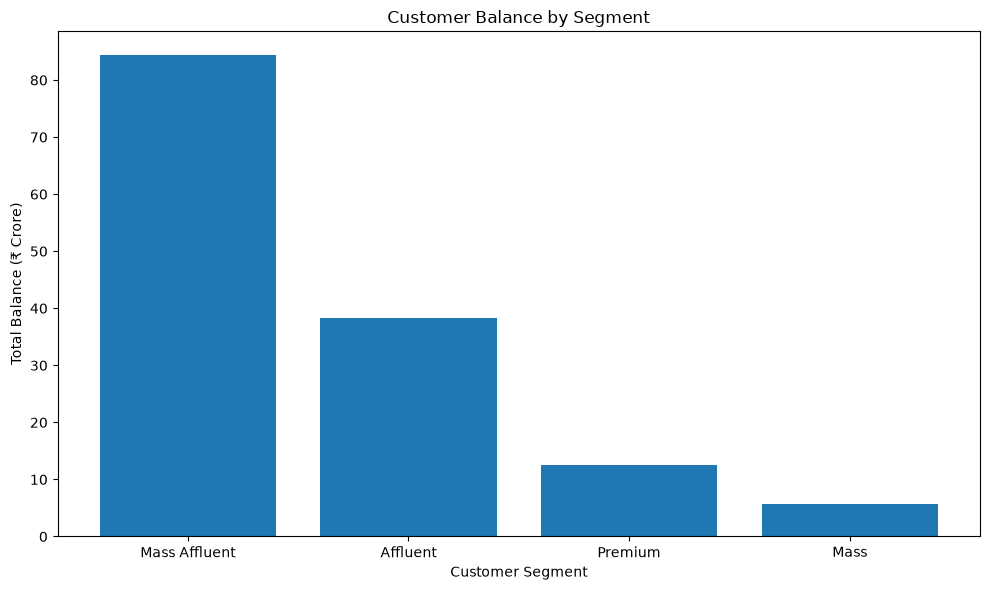

In [53]:
segment_balance = (
    customers
    .groupby("Customer_Segment", observed=True)["Account_Balance"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    segment_balance.index.astype(str),
    segment_balance.values / 10000000
)

plt.title("Customer Balance by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Balance (₹ Crore)")

plt.tight_layout()
plt.show()

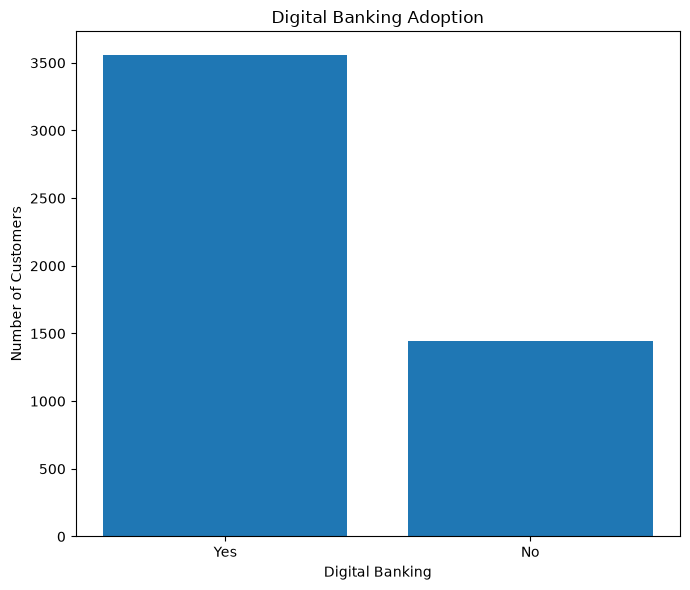

In [54]:
digital_counts = (
    customers["Digital_Banking"]
    .value_counts()
)

plt.figure(figsize=(7, 6))

plt.bar(
    digital_counts.index,
    digital_counts.values
)

plt.title("Digital Banking Adoption")
plt.xlabel("Digital Banking")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [55]:
digital_adoption = (
    customers["Digital_Banking"].eq("Yes").mean() * 100
)

print(
    f"Digital Banking Adoption: {digital_adoption:.2f}%"
)

Digital Banking Adoption: 71.10%


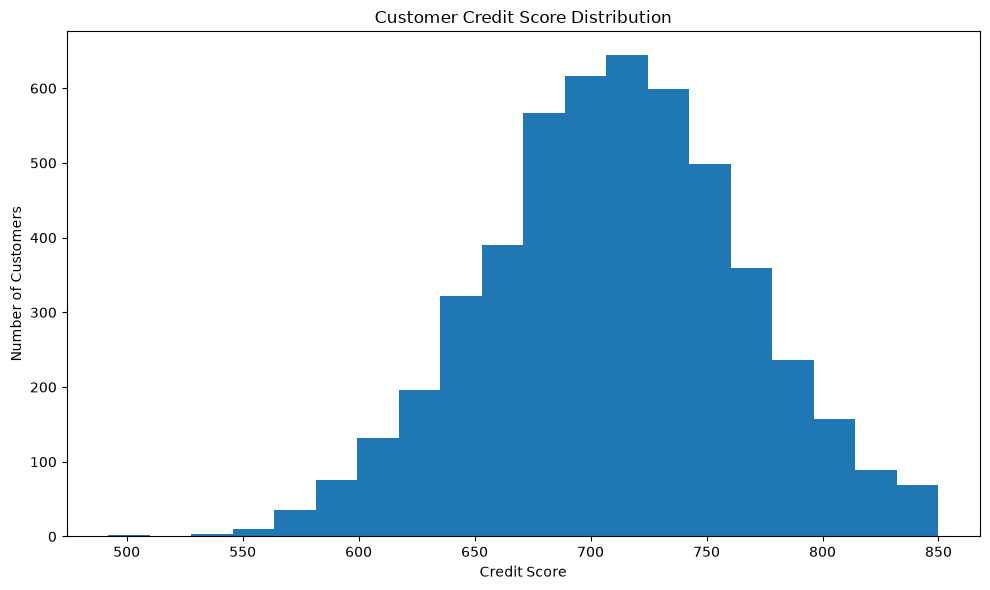

In [56]:
plt.figure(figsize=(10, 6))

plt.hist(
    customers["Credit_Score"],
    bins=20
)

plt.title("Customer Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [57]:
loan_data = customers[
    customers["Loan_Type"].notna()
]

loan_analysis = (
    loan_data
    .groupby("Loan_Type")
    .agg(
        Customers=("Customer_ID", "count"),
        Total_Loan=("Loan_Amount", "sum"),
        Average_Loan=("Loan_Amount", "mean")
    )
    .reset_index()
)

loan_analysis

,Loan_Type,Customers,Total_Loan,Average_Loan
0,Education Loan,204,64581000,3.165735e+05
1,Home Loan,485,814166000,1.678693e+06
2,Personal Loan,799,362099000,4.531902e+05
3,Vehicle Loan,454,150187000,3.308084e+05


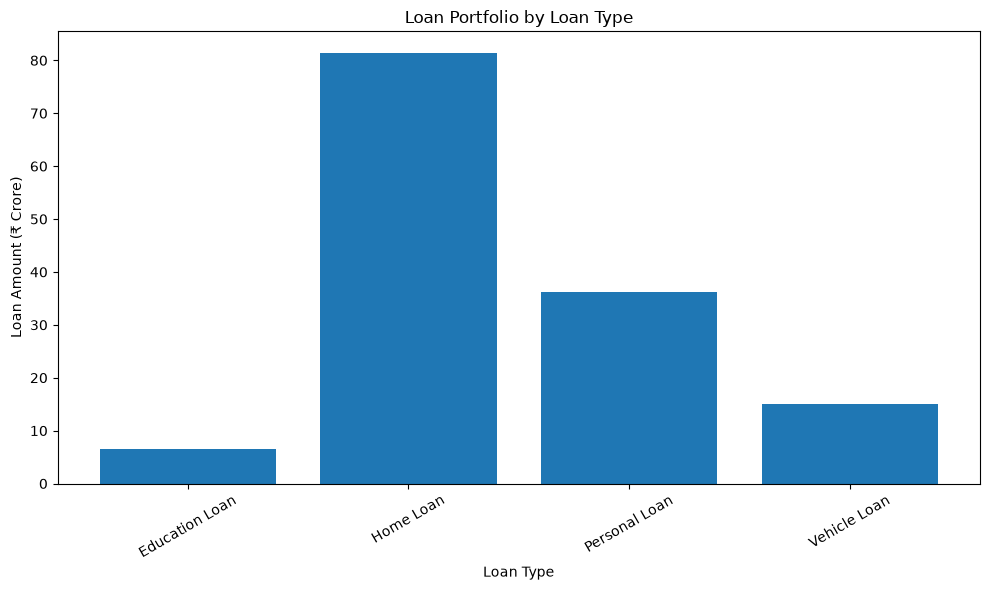

In [58]:
plt.figure(figsize=(10, 6))

plt.bar(
    loan_analysis["Loan_Type"],
    loan_analysis["Total_Loan"] / 10000000
)

plt.title("Loan Portfolio by Loan Type")
plt.xlabel("Loan Type")
plt.ylabel("Loan Amount (₹ Crore)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

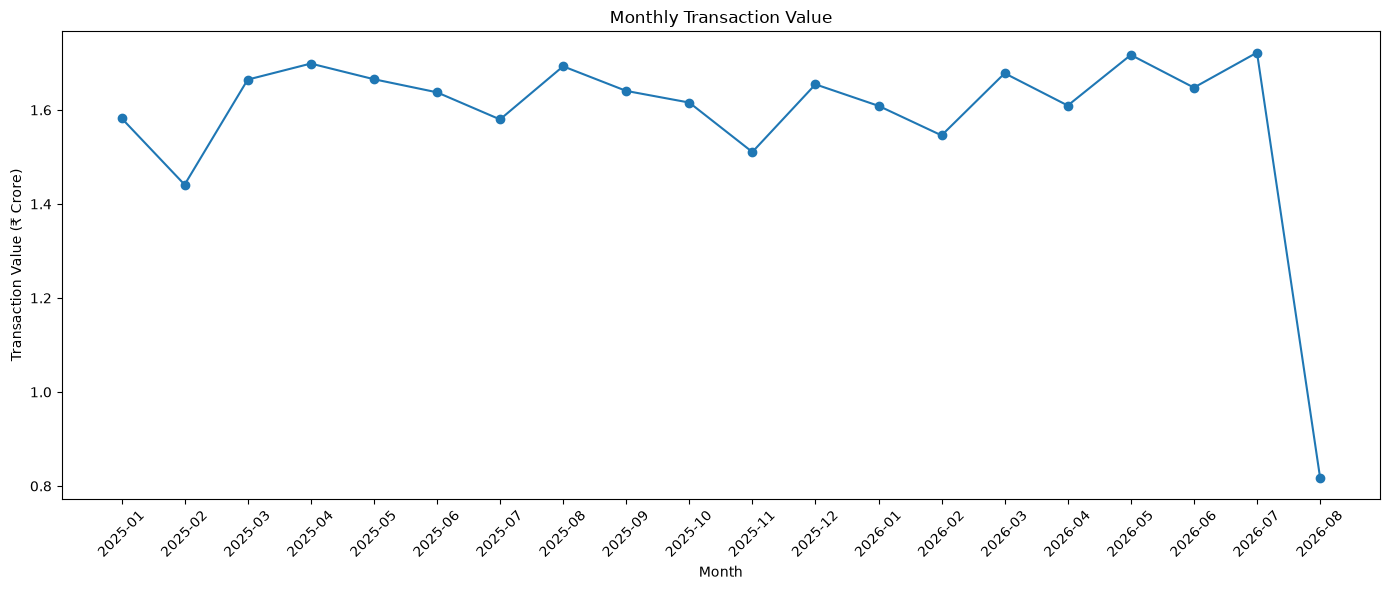

In [59]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_transactions["Year_Month"],
    monthly_transactions["Total_Amount"] / 10000000,
    marker="o"
)

plt.title("Monthly Transaction Value")
plt.xlabel("Month")
plt.ylabel("Transaction Value (₹ Crore)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [60]:
final_summary = {
    "Total Customers": customers["Customer_ID"].nunique(),

    "Total Balance": customers["Account_Balance"].sum(),

    "Total Loans": customers["Loan_Amount"].sum(),

    "Average Balance": customers["Account_Balance"].mean(),

    "Average Credit Score": customers["Credit_Score"].mean(),

    "Active Customers": (
        customers["Customer_Status"] == "Active"
    ).sum(),

    "Digital Banking Customers": (
        customers["Digital_Banking"] == "Yes"
    ).sum(),

    "Potential Loan Customers": len(loan_opportunity),

    "Dormant High Value Customers": len(
        dormant_high_value
    )
}

final_summary

{'Total Customers': 5000,
 'Total Balance': np.int64(1408521100),
 'Total Loans': np.int64(1391033000),
 'Average Balance': np.float64(281704.22),
 'Average Credit Score': np.float64(710.2664),
 'Active Customers': np.int64(4547),
 'Digital Banking Customers': np.int64(3555),
 'Potential Loan Customers': 408,
 'Dormant High Value Customers': 237}

In [61]:
top_branch = branch_analysis.loc[
    branch_analysis["Total_Balance"].idxmax()
]

top_segment = balance_analysis.loc[
    balance_analysis["Total_Balance"].idxmax()
]

top_transaction_channel = channel_analysis.loc[
    channel_analysis["Transactions"].idxmax()
]

print("TOP BRANCH")
print(
    top_branch["Branch"],
    "with balance ₹{:,.0f}".format(
        top_branch["Total_Balance"]
    )
)

print("\nTOP CUSTOMER SEGMENT")
print(
    top_segment["Customer_Segment"],
    "with balance ₹{:,.0f}".format(
        top_segment["Total_Balance"]
    )
)

print("\nMOST USED TRANSACTION CHANNEL")
print(
    top_transaction_channel["Channel"],
    "with",
    top_transaction_channel["Transactions"],
    "transactions"
)

TOP BRANCH
Kolhapur Main with balance ₹111,224,500

TOP CUSTOMER SEGMENT
Mass Affluent with balance ₹843,228,200

MOST USED TRANSACTION CHANNEL
Mobile Banking with 15131 transactions
